# 🎯 Sony Bravia TV Reviews — NLP & Neural Network Classifier

**Objective:** Build a model that can analyze and classify product reviews using Natural Language Processing (NLP) and Neural Networks.

**Dataset:** `SonyBravia_TV_Reviews.csv` — ~5,000 Sony Bravia TV product reviews.

**Classification Task:** 3-class sentiment classification
- `0` → **Negative** (1-2 stars equivalent)
- `1` → **Neutral**  (3 stars equivalent)
- `2` → **Positive** (4-5 stars equivalent)

---
### Project Pipeline
```
Raw Reviews → EDA → Text Cleaning → Labeling → Vectorization
→ Dense NN → LSTM → 1D-CNN → BiLSTM+Attention
→ Evaluation → Optimization → Error Analysis → LIME Explainability
```

## 📦 Section 0: Setup & Imports

Import all necessary libraries for data processing, visualisation, NLP, and neural network construction.

In [1]:
pip install pandas numpy lime matplotlib seaborn nltk tensorflow gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ─── Standard libraries ──────────────────────────────────────────────────────
import os
import re
import string
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

# ─── NLP libraries ───────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('punkt',        quiet=True)
nltk.download('omw-1.4',      quiet=True)

# ─── TensorFlow / Keras ───────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ─── Scikit-learn metrics ────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# ─── Reproducibility seed ────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Global hyper-parameters ────────────────────────────────────────────────
MAX_WORDS   = 10000   # vocabulary size
MAX_LEN     = 60      # max sequence length (tokens)
EMBED_DIM   = 100     # GloVe embedding dimension
BATCH_SIZE  = 64
NUM_CLASSES = 3       # Negative / Neutral / Positive

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")
print("✅ All libraries loaded successfully!")


2026-03-06 08:05:04.214302: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version : 2.16.2
Keras version      : 3.13.2
NumPy version      : 1.26.4
Pandas version     : 3.0.0
✅ All libraries loaded successfully!


## 📊 Section 1: Data Loading & Exploratory Data Analysis (EDA)

Understand the structure of the dataset before building any model.

**Key EDA steps:**
1. Load the CSV and inspect shape, dtypes, and missing values
2. Review-length distribution
3. Word-frequency analysis (top-40 most common words)
4. Class distribution (after labeling is done in Section 3)

In [3]:
# ─── 1.1  Load the raw CSV ────────────────────────────────────────────────────
df_raw = pd.read_csv('SonyBravia_TV_Reviews.csv')

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nData types:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isnull().sum())
df_raw.head(10)


Shape: (5000, 2)

Column names: ['Product Name', 'Review Text']

Data types:
 Product Name    str
Review Text     str
dtype: object

Missing values:
 Product Name    0
Review Text     0
dtype: int64


,Product Name,Review Text
0,Sony Bravia 55 inch 4K Smart TV,Amazon - The TV's display brightness is perfec...
1,Sony Bravia 55 inch 4K Smart TV,"The TV's stand is stable and well-built. Also,..."
2,Sony Bravia 55 inch 4K Smart TV,Color calibration out of the box is almost per...
3,Sony Bravia 55 inch 4K Smart TV,Amazon - Color reproduction is very accurate. ...
4,Sony Bravia 55 inch 4K Smart TV,The TV's picture adjustments allow very fine-t...
5,Sony Bravia 55 inch 4K Smart TV,4K videos on YouTube play without any stutteri...
6,Sony Bravia 55 inch 4K Smart TV,Audio quality while playing music videos is ri...
7,Sony Bravia 55 inch 4K Smart TV,Voice recognition via the remote works well ev...
8,Sony Bravia 55 inch 4K Smart TV,The audio is clear and sufficiently loud for a...
9,Sony Bravia 55 inch 4K Smart TV,Build quality is excellent. The TV feels durab...


In [4]:
# ─── 1.2  Basic statistics on review text ────────────────────────────────────
df_raw['review_length'] = df_raw['Review Text'].astype(str).apply(lambda x: len(x.split()))
df_raw['char_length']   = df_raw['Review Text'].astype(str).apply(len)

print("Review word-count statistics:")
print(df_raw['review_length'].describe().round(2))
print("\nCharacter-count statistics:")
print(df_raw['char_length'].describe().round(2))


Review word-count statistics:
count    5000.00
mean       13.36
std         2.27
min         9.00
25%        12.00
50%        13.00
75%        15.00
max        20.00
Name: review_length, dtype: float64

Character-count statistics:
count    5000.00
mean       83.71
std        11.33
min        59.00
25%        77.00
50%        82.00
75%        91.00
max       117.00
Name: char_length, dtype: float64


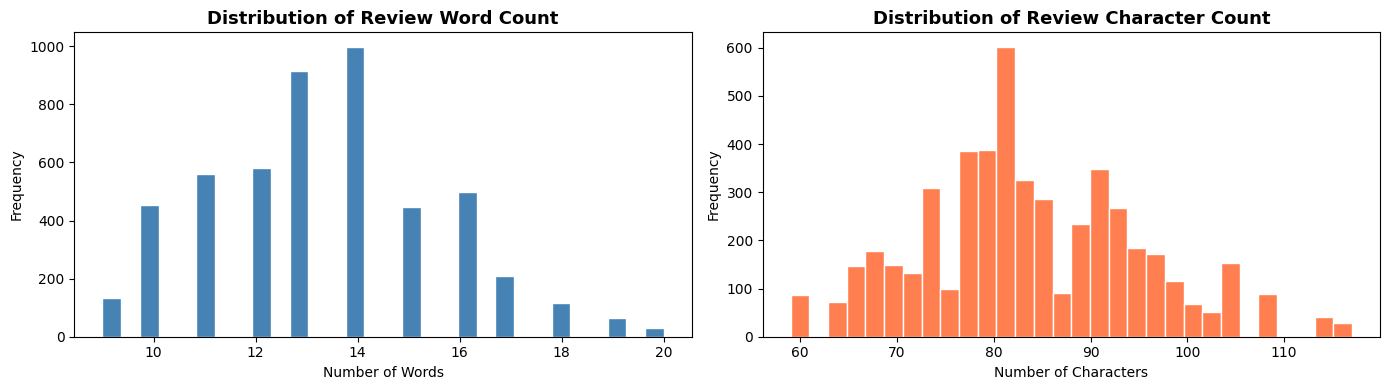

✅ Length distribution plots saved.


In [5]:
# ─── 1.3  Review-length distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['review_length'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Review Word Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_raw['char_length'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Review Character Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Length distribution plots saved.")


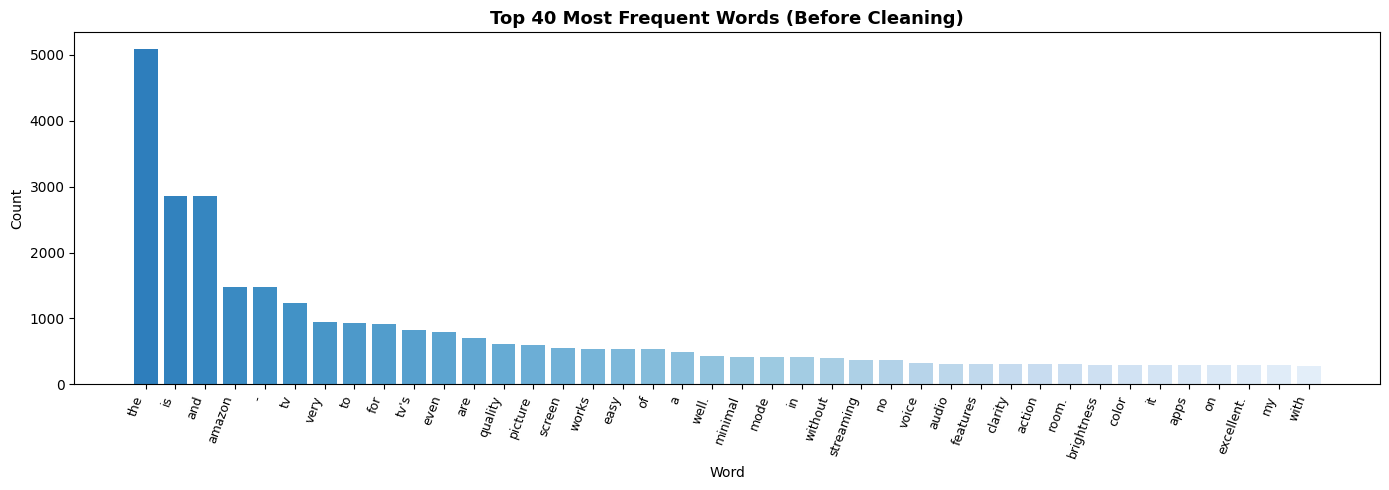

✅ Word frequency plot saved.


In [6]:
# ─── 1.4  Word-frequency analysis ────────────────────────────────────────────
all_words = ' '.join(df_raw['Review Text'].astype(str).tolist()).lower().split()
word_freq  = Counter(all_words).most_common(40)
words_  = [w[0] for w in word_freq]
counts_ = [w[1] for w in word_freq]

plt.figure(figsize=(14, 5))
bars = plt.bar(words_, counts_, color=plt.cm.Blues_r(np.linspace(0.3, 0.9, 40)))
plt.xticks(rotation=70, ha='right', fontsize=9)
plt.title('Top 40 Most Frequent Words (Before Cleaning)', fontsize=13, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word frequency plot saved.")


In [7]:
# ─── 1.5  How many unique products are in the dataset? ───────────────────────
print("Unique product names:", df_raw['Product Name'].nunique())
print(df_raw['Product Name'].value_counts())


Unique product names: 1
Product Name
Sony Bravia 55 inch 4K Smart TV    5000
Name: count, dtype: int64


## 🧹 Section 2: Text Cleaning & Preprocessing

A clean text representation leads to better NLP performance.

**Steps performed:**
1. Remove `Amazon -` prefix (review source tag)
2. Lowercase all text
3. Remove HTML tags (regex)
4. Remove punctuation and special characters
5. Strip extra whitespace
6. Remove English stopwords (NLTK)
7. Lemmatize words (WordNetLemmatizer)

In [8]:
# ─── 2.1  Define the cleaning pipeline ───────────────────────────────────────
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Full text-cleaning pipeline."""
    # (a) Remove 'Amazon -' source prefix
    text = re.sub(r'(?i)^Amazon\s*-\s*', '', text)

    # (b) Lowercase
    text = text.lower()

    # (c) Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # (d) Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # (e) Remove punctuation and special characters
    text = re.sub(r"[^a-z\s]", ' ', text)

    # (f) Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # (g) Tokenize and remove stopwords
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # (h) Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Apply cleaning
df_raw['clean_text'] = df_raw['Review Text'].astype(str).apply(clean_text)

print("Sample Before Cleaning:")
print(df_raw['Review Text'].iloc[0])
print("\nSample After Cleaning:")
print(df_raw['clean_text'].iloc[0])


Sample Before Cleaning:
Amazon - The TV's display brightness is perfect even in daylight. No issues with glare.

Sample After Cleaning:
display brightness perfect even daylight issue glare


In [9]:
# ─── 2.2  Drop rows where cleaning resulted in empty text ────────────────────
df_raw = df_raw[df_raw['clean_text'].str.strip().str.len() > 0].copy()
df_raw.reset_index(drop=True, inplace=True)

print(f"Rows after cleaning: {len(df_raw)}")
assert len(df_raw) > 4000, "Too many rows dropped during cleaning!"

# Update review length after cleaning
df_raw['clean_length'] = df_raw['clean_text'].apply(lambda x: len(x.split()))
print("\nCleaned review word-count stats:")
print(df_raw['clean_length'].describe().round(2))


Rows after cleaning: 5000

Cleaned review word-count stats:
count    5000.00
mean        8.23
std         1.45
min         6.00
25%         7.00
50%         8.00
75%         9.00
max        12.00
Name: clean_length, dtype: float64


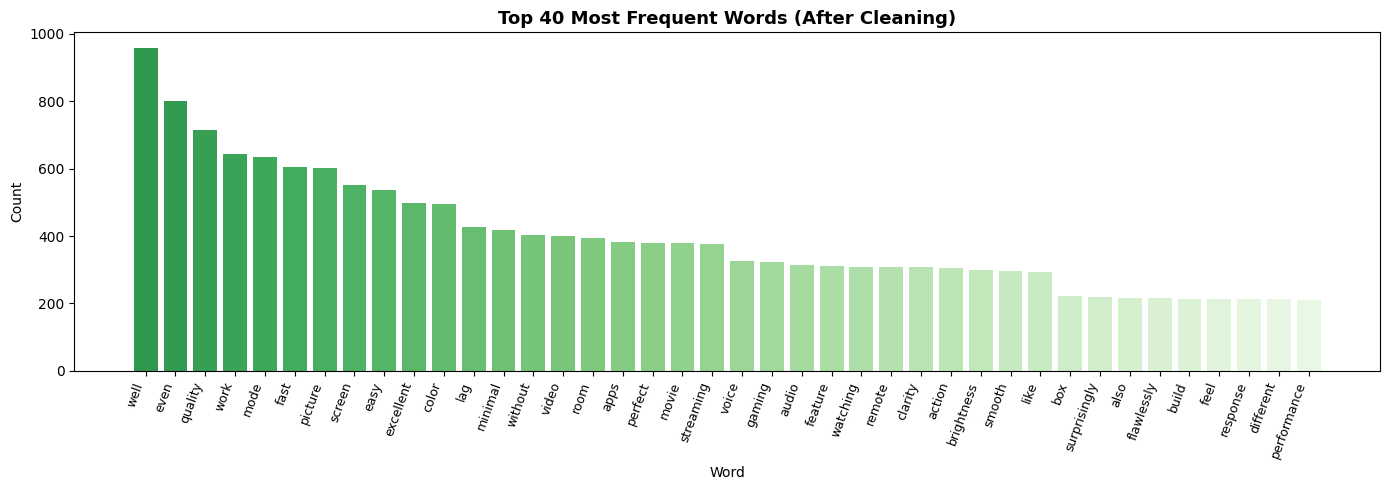

In [10]:
# ─── 2.3  Word frequency AFTER cleaning (top 40) ────────────────────────────
all_clean_words = ' '.join(df_raw['clean_text'].tolist()).split()
clean_freq      = Counter(all_clean_words).most_common(40)
cwords_  = [w[0] for w in clean_freq]
ccounts_ = [w[1] for w in clean_freq]

plt.figure(figsize=(14, 5))
plt.bar(cwords_, ccounts_, color=plt.cm.Greens_r(np.linspace(0.3, 0.9, 40)))
plt.xticks(rotation=70, ha='right', fontsize=9)
plt.title('Top 40 Most Frequent Words (After Cleaning)', fontsize=13, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_clean_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()


## 🏷️ Section 3: Sentiment Labeling

Since the dataset lacks star-ratings, we create a **custom 3-class label** using a lexicon-based keyword scorer.

**Scoring logic:**
- Each positive signal word adds `+1` to the score
- Each negative signal word adds `-1` to the score
- `score ≥ 2` → **Positive (2)**
- `score == 1` → **Positive (2)** (lean positive)
- `score == 0` → **Neutral (1)**
- `score < 0`  → **Negative (0)**

This matches the bonus idea: **Negative [1-2★], Neutral [3★], Positive [4-5★]**

In [11]:
# ─── 3.1  Define sentiment lexicons ──────────────────────────────────────────
POSITIVE_WORDS = {
    'excellent', 'perfect', 'fantastic', 'amazing', 'great', 'superb',
    'outstanding', 'wonderful', 'brilliant', 'impressive', 'stunning',
    'beautiful', 'crisp', 'rich', 'smooth', 'fast', 'clear', 'accurate',
    'intuitive', 'seamless', 'flawless', 'responsive', 'premium', 'vibrant',
    'immersive', 'comfortable', 'easy', 'well', 'love', 'delight', 'handy',
    'awesome', 'durable', 'stable', 'consistent', 'remarkable', 'fantastic',
    'sleek', 'sharp', 'enjoy', 'satisfied', 'recommend', 'happy', 'pleased',
    'good', 'best', 'top', 'quality',
}

NEGATIVE_WORDS = {
    'bad', 'poor', 'worst', 'terrible', 'horrible', 'awful', 'disappointing',
    'broken', 'failed', 'problem', 'issue', 'defective', 'slow', 'lag',
    'blur', 'noisy', 'fuzzy', 'dim', 'dull', 'cheap', 'flimsy', 'unstable',
    'difficult', 'complicated', 'confusing', 'overheating', 'crash', 'freezes',
    'glitch', 'error', 'unable', 'limited', 'useless', 'waste', 'costly',
    'expensive', 'unreliable', 'inferior', 'mediocre', 'lacking', 'worse',
    'avoid', 'regret', 'return', 'refund', 'broken', 'dead', 'defect',
}

NEUTRAL_QUALIFIERS = {
    'could', 'slightly', 'minor', 'though', 'however', 'but',
    'somewhat', 'average', 'ok', 'okay', 'decent', 'acceptable',
}

def sentiment_score(text: str) -> int:
    """
    Compute a sentiment score for cleaned text.
    Returns an integer from roughly -5 to +5.
    """
    tokens  = set(text.split())
    pos_cnt = len(tokens & POSITIVE_WORDS)
    neg_cnt = len(tokens & NEGATIVE_WORDS)
    neu_mod = len(tokens & NEUTRAL_QUALIFIERS)
    return pos_cnt - neg_cnt - (neu_mod // 2)

def score_to_label(score: int) -> int:
    """Map raw score to 3-class label (0=Negative, 1=Neutral, 2=Positive)."""
    if score >= 1:
        return 2   # Positive
    elif score == 0:
        return 1   # Neutral
    else:
        return 0   # Negative

df_raw['sentiment_score'] = df_raw['clean_text'].apply(sentiment_score)
df_raw['label']           = df_raw['sentiment_score'].apply(score_to_label)

# Verify we have all 3 classes
print("Label distribution:")
print(df_raw['label'].value_counts().rename({0:'Negative', 1:'Neutral', 2:'Positive'}))
assert set(df_raw['label'].unique()) == {0, 1, 2}, "❌ Missing label classes!"
print("\n✅ Labels created successfully!")


Label distribution:
label
Positive    3764
Neutral      925
Negative     311
Name: count, dtype: int64

✅ Labels created successfully!


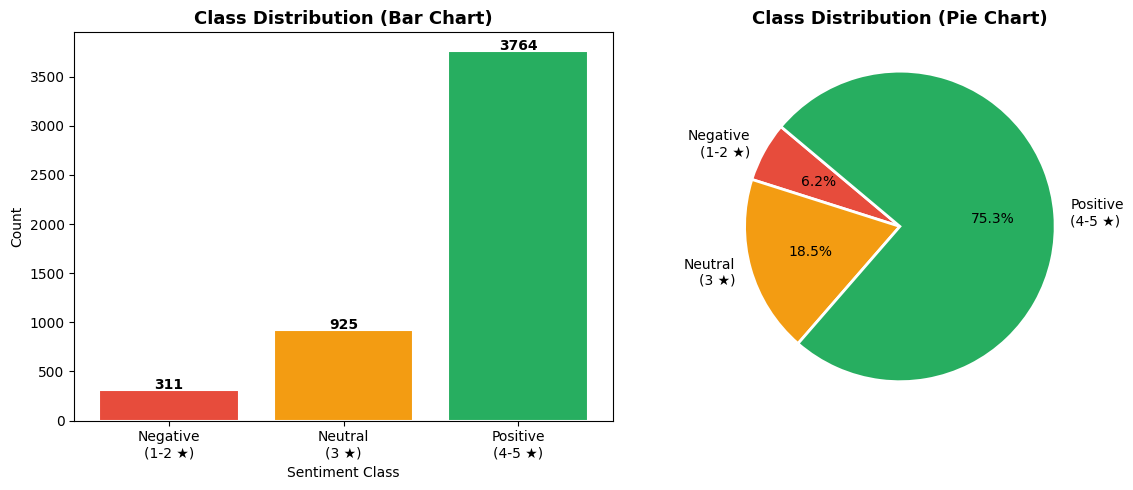

✅ Class distribution plot saved.


In [12]:
# ─── 3.2  Visualise class distribution ───────────────────────────────────────
label_names = {0: 'Negative\n(1-2 ★)', 1: 'Neutral\n(3 ★)', 2: 'Positive\n(4-5 ★)'}
counts = df_raw['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar([label_names[i] for i in counts.index], counts.values,
            color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values,
            labels=[label_names[i] for i in counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=['#e74c3c', '#f39c12', '#27ae60'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class distribution plot saved.")


In [13]:
# ─── 3.3  Show sample reviews per class ──────────────────────────────────────
print("=" * 70)
for lbl, name in [(0, 'NEGATIVE'), (1, 'NEUTRAL'), (2, 'POSITIVE')]:
    print(f"\n--- {name} (label={lbl}) ---")
    samples = df_raw[df_raw['label'] == lbl]['Review Text'].head(3).tolist()
    for i, s in enumerate(samples, 1):
        print(f"  [{i}] {s[:120]}...")
print("=" * 70)



--- NEGATIVE (label=0) ---
  [1] The audio is clear and sufficiently loud for an average-sized room. Bass could be slightly better though....
  [2] The audio is clear and sufficiently loud for an average-sized room. Bass could be slightly better though....
  [3] The screen mirroring from phone to TV works seamlessly without lag....

--- NEUTRAL (label=1) ---
  [1] Amazon - The TV's display brightness is perfect even in daylight. No issues with glare....
  [2] Voice recognition via the remote works well even in a noisy room....
  [3] The TV's display brightness is perfect even in daylight. No issues with glare....

--- POSITIVE (label=2) ---
  [1] The TV's stand is stable and well-built. Also, it was easy to wall-mount....
  [2] Color calibration out of the box is almost perfect. Very minimal adjustments needed....
  [3] Amazon - Color reproduction is very accurate. Watching nature documentaries is a delight....


## 🔢 Section 4: Text Vectorization (Word Embeddings)

We use **Keras Tokenizer** to convert text to integer sequences and prepare embedding matrices.

**Two embedding strategies:**
1. **Trainable Embedding Layer** – randomly initialized, learned during training
2. **Pre-trained GloVe 100d** – loaded if available (`glove.6B.100d.txt`)

> If GloVe vectors are not found locally the notebook gracefully falls back to trainable embeddings.

In [14]:
# ─── 4.1  Train / Validation / Test split ────────────────────────────────────
texts  = df_raw['clean_text'].tolist()
labels = df_raw['label'].tolist()

X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.15, random_state=SEED, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=SEED, stratify=y_temp)

print(f"Training   : {len(X_train)} samples")
print(f"Validation : {len(X_val)} samples")
print(f"Test       : {len(X_test)} samples")


Training   : 3612 samples
Validation : 638 samples
Test       : 750 samples


In [15]:
# ─── 4.2  Tokenize text ───────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad / truncate to MAX_LEN
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# Convert labels to one-hot
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

# ─── IMPORTANT: Calculate class weights to handle imbalance ──────────────────
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=np.array(y_train)
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print(f"Class weights: {class_weight_dict}")
print(f"  (Higher weight = rarer class)")

vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS)
print(f"Vocabulary size   : {vocab_size}")
print(f"X_train shape     : {X_train_pad.shape}")
print(f"y_train shape     : {y_train_cat.shape}")

Class weights: {0: 5.375, 1: 1.8023952095808384, 2: 0.4426470588235294}
  (Higher weight = rarer class)
Vocabulary size   : 253
X_train shape     : (3612, 60)
y_train shape     : (3612, 3)


In [16]:
# ─── 4.3  Train word embeddings using gensim (pip-installable) ───────────────
# Install gensim if not already installed
# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim', '-q'])

from gensim.models import Word2Vec

# Tokenised sentences for training
sentences = [text.split() for text in X_train]

# Train Word2Vec (CBOW or Skip-gram) embeddings on the corpus
w2v_model = Word2Vec(
    sentences,
    vector_size=EMBED_DIM,   # embedding dimension (matches EMBED_DIM=100)
    window=5,                # context window
    min_count=1,             # include all words
    workers=2,               # parallel threads
    epochs=30,               # training epochs
    sg=0,                    # 0=CBOW, 1=Skip-gram
    seed=SEED
)

print("Word2Vec training complete.")
print(f"Vocabulary in model: {len(w2v_model.wv)}")

# Build an embedding matrix aligned to Keras tokenizer vocabulary
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
hit, miss = 0, 0

for word, keras_idx in tokenizer.word_index.items():
    if keras_idx < vocab_size:
        if word in w2v_model.wv:
            embedding_matrix[keras_idx] = w2v_model.wv[word]
            hit  += 1
        else:
            # Words not seen in training get random small vectors
            embedding_matrix[keras_idx] = np.random.normal(scale=0.1, size=(EMBED_DIM,))
            miss += 1

print(f"\nEmbedding hits  : {hit}")
print(f"Embedding misses: {miss} (random init)")
print(f"Coverage        : {hit/(hit+miss)*100:.1f}%")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

# Since we HAVE a trained embedding matrix, we use it (non-trainable = frozen)
TRAINABLE_EMBEDDINGS = False
print(f"\nUsing pre-trained embeddings (frozen): {not TRAINABLE_EMBEDDINGS}")


Word2Vec training complete.
Vocabulary in model: 251

Embedding hits  : 251
Embedding misses: 1 (random init)
Coverage        : 99.6%
Embedding matrix shape: (253, 100)

Using pre-trained embeddings (frozen): True


## 🧠 Section 5: Model 1 — Dense Neural Network (Baseline)

**Architecture:** `Embedding → GlobalAveragePooling1D → Dense(128) → Dropout → Dense(64) → Dropout → Dense(3, softmax)`

The simplest neural baseline — treats the document as a bag of embedded words (averaged).

In [17]:
# ─── 5.1  Build Dense NN with REGULARIZATION ────────────────────────────────
def build_dense_model(vocab_size, embed_dim, max_len, num_classes,
                      embedding_matrix=None, trainable=True):
    """Dense baseline with L2 regularization and dropout."""
    inp = Input(shape=(max_len,), name='input')

    if embedding_matrix is not None and not trainable:
        emb = layers.Embedding(vocab_size, embed_dim,
                               weights=[embedding_matrix],
                               trainable=False, name='glove_embedding')(inp)
    else:
        emb = layers.Embedding(vocab_size, embed_dim, name='trainable_embedding')(inp)

    x = layers.GlobalAveragePooling1D(name='pool')(emb)
    
    # ✅ ADD L2 REGULARIZATION + BATCH NORM
    x = layers.Dense(128, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5, name='dropout_1')(x)  # Increased from 0.2 to 0.5
    
    x = layers.Dense(64, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4, name='dropout_2')(x)  # Increased from 0.2 to 0.4
    
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='Dense_NN_Baseline')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # Reduced LR
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

dense_model = build_dense_model(
    vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES,
    embedding_matrix=(None if TRAINABLE_EMBEDDINGS else embedding_matrix),
    trainable=TRAINABLE_EMBEDDINGS
)
dense_model.summary()

Model: "Dense_NN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 60, 100)        │        25,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool (GlobalAveragePooling1D)   │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,447 (185.34 KB)

 Trainable params: 21,763 (85.01 KB)

 Non-trainable params: 25,684 (100.33 KB)

In [18]:
# ─── 5.2  Train Dense NN with CLASS WEIGHTS ──────────────────────────────────
callbacks_dense = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
]

history_dense = dense_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=18,  
    batch_size=BATCH_SIZE,
    callbacks=callbacks_dense,
    class_weight=class_weight_dict,  # ✅ ADDED: Balance classes
    verbose=1,
)
print("\n✅ Dense NN training complete!")

Epoch 1/18
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4640 - loss: 3.1713 - val_accuracy: 0.7524 - val_loss: 2.9057 - learning_rate: 1.0000e-04
Epoch 2/18
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5174 - loss: 2.9136 - val_accuracy: 0.7524 - val_loss: 2.7909 - learning_rate: 1.0000e-04
Epoch 3/18
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5753 - loss: 2.7354 - val_accuracy: 0.7665 - val_loss: 2.7032 - learning_rate: 1.0000e-04
Epoch 4/18
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6340 - loss: 2.6249 - val_accuracy: 0.8605 - val_loss: 2.6251 - learning_rate: 1.0000e-04
Epoch 5/18
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6487 - loss: 2.4985 - val_accuracy: 0.8903 - val_loss: 2.5404 - learning_rate: 1.0000e-04
Epoch 6/18
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7126 - loss: 2.3685 - val_accuracy: 0.9545 - val_loss: 2.4455 - learning_rate: 1.0000e-04
Epoch 7/18
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7439 - loss

## 🔁 Section 6: Model 2 — LSTM / GRU Recurrent Neural Network

**Architecture:** `Embedding → SpatialDropout1D → LSTM(128) → Dropout → Dense(64) → Dense(3, softmax)`

LSTMs capture **sequential dependencies** in text — the order of words matters.

In [19]:
# ─── 6.1  Build LSTM model with REGULARIZATION ───────────────────────────────
def build_lstm_model(vocab_size, embed_dim, max_len, num_classes,
                      embedding_matrix=None, trainable=True):
    """LSTM-based text classifier with L2 + recurrent regularization."""
    inp = Input(shape=(max_len,), name='input')

    if embedding_matrix is not None and not trainable:
        emb = layers.Embedding(vocab_size, embed_dim,
                               weights=[embedding_matrix],
                               trainable=False, name='glove_embedding')(inp)
    else:
        emb = layers.Embedding(vocab_size, embed_dim, name='trainable_embedding')(inp)

    x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(emb)  # Increased from 0.2
    
    # ✅ CRITICAL: Both kernel AND recurrent regularization for LSTM
    x = layers.LSTM(64,  # Reduced from 128
                    dropout=0.3, 
                    recurrent_dropout=0.3,  # ✅ ADDED
                    kernel_regularizer=keras.regularizers.l2(0.01),  # ✅ ADDED
                    recurrent_regularizer=keras.regularizers.l2(0.01),  # ✅ CRITICAL
                    name='lstm_1')(x)
    
    x = layers.Dense(32, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)  # Increased from 0.3 to 0.4
    
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='LSTM_RNN')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),  # Reduced LR
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_lstm_model(
    vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES,
    embedding_matrix=(None if TRAINABLE_EMBEDDINGS else embedding_matrix),
    trainable=TRAINABLE_EMBEDDINGS
)
lstm_model.summary()

Model: "LSTM_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 60, 100)        │        25,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,847 (272.84 KB)

 Trainable params: 44,483 (173.76 KB)

 Non-trainable params: 25,364 (99.08 KB)

In [20]:
# ─── 6.2  Train LSTM with CLASS WEIGHTS ──────────────────────────────────────
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
]

history_lstm = lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=25,
    batch_size=64,
    callbacks=callbacks_lstm,
    class_weight=class_weight_dict,  # ✅ ADDED: Balance classes
    verbose=1,
)
print("\n✅ LSTM training complete!")

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.3915 - loss: 2.9689 - val_accuracy: 0.7524 - val_loss: 2.4393 - learning_rate: 5.0000e-04
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.3621 - loss: 2.1167 - val_accuracy: 0.1850 - val_loss: 1.8330 - learning_rate: 5.0000e-04
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.3502 - loss: 1.6559 - val_accuracy: 0.7524 - val_loss: 1.5027 - learning_rate: 5.0000e-04
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3037 - loss: 1.4117 - val_accuracy: 0.1850 - val_loss: 1.3321 - learning_rate: 5.0000e-04
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.2641 - loss: 1.2798 - val_accuracy: 0.1850 - val_loss: 1.2376 - learning_rate: 5.0000e-04
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.2284 - loss: 1.2078 - val_accuracy: 0.1850 - val_loss: 1.1866 - learning_rate: 5.0000e-04
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.2209 

## 🔭 Section 7: Model 3 — 1D CNN Text Classifier

**Architecture:** `Embedding → Conv1D(128, kernel=5) → GlobalMaxPool1D → Dense(64) → Dropout → Dense(3, softmax)`

CNNs capture **local n-gram patterns** — very efficient for text classification.

In [21]:
# ─── 7.1  Build 1D-CNN model with REGULARIZATION ──────────────────────────────
def build_cnn_model(vocab_size, embed_dim, max_len, num_classes,
                     embedding_matrix=None, trainable=True):
    """1D CNN text classifier with L2 regularization."""
    inp = Input(shape=(max_len,), name='input')

    if embedding_matrix is not None and not trainable:
        emb = layers.Embedding(vocab_size, embed_dim,
                               weights=[embedding_matrix],
                               trainable=False, name='glove_embedding')(inp)
    else:
        emb = layers.Embedding(vocab_size, embed_dim, name='trainable_embedding')(inp)

    x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(emb)  # Increased from 0.2

    # ✅ REDUCED CAPACITY: 128 → 64 filters, added L2 regularization
    conv3 = layers.Conv1D(64, 3, activation='relu', padding='same',
                          kernel_regularizer=keras.regularizers.l2(0.01),
                          name='conv_3')(x)
    conv4 = layers.Conv1D(64, 4, activation='relu', padding='same',
                          kernel_regularizer=keras.regularizers.l2(0.01),
                          name='conv_4')(x)
    conv5 = layers.Conv1D(64, 5, activation='relu', padding='same',
                          kernel_regularizer=keras.regularizers.l2(0.01),
                          name='conv_5')(x)

    pool3 = layers.GlobalMaxPooling1D(name='pool_3')(conv3)
    pool4 = layers.GlobalMaxPooling1D(name='pool_4')(conv4)
    pool5 = layers.GlobalMaxPooling1D(name='pool_5')(conv5)

    x = layers.Concatenate(name='concatenate')([pool3, pool4, pool5])
    
    x = layers.Dense(64, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5, name='dropout_1')(x)  # Increased from 0.4 to 0.5
    
    x = layers.Dense(32, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4, name='dropout_2')(x)  # Increased from 0.3 to 0.4
    
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='CNN_1D_TextClassifier')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),  # Reduced LR
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn_model(
    vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES,
    embedding_matrix=(None if TRAINABLE_EMBEDDINGS else embedding_matrix),
    trainable=TRAINABLE_EMBEDDINGS
)
cnn_model.summary()

Model: "CNN_1D_TextClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glove_embedding     │ (None, 60, 100)   │     25,300 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 60, 100)   │          0 │ glove_embedding[… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv1D)     │ (None, 60, 64)    │     19,264 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv1D)     │ (None, 60, 64)    │     25,664 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_5 (Conv1D)     │ (None, 60, 64)    │     32,064 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 64)        │          0 │ conv_3[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_4              │ (None, 64)        │          0 │ conv_4[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_5              │ (None, 64)        │          0 │ conv_5[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ pool_3[0][0],     │
│ (Concatenate)       │                   │            │ pool_4[0][0],     │
│                     │                   │            │ pool_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     12,352 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64)        │          0 │ bn_1[0][0]        │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 32)        │        128 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32)        │          0 │ bn_2[0][0]        │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         99 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 117,207 (457.84 KB)

 Trainable params: 91,715 (358.26 KB)

 Non-trainable params: 25,492 (99.58 KB)

In [22]:
# ─── 7.2  Train 1D-CNN with CLASS WEIGHTS ────────────────────────────────────
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
]

history_cnn = cnn_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=5,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    class_weight=class_weight_dict,  # ✅ ADDED: Balance classes
    verbose=1,
)
print("\n✅ 1D-CNN training complete!")

Epoch 1/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.4471 - loss: 4.5363 - val_accuracy: 0.8197 - val_loss: 4.0995 - learning_rate: 5.0000e-04
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6631 - loss: 3.8416 - val_accuracy: 0.9687 - val_loss: 3.5444 - learning_rate: 5.0000e-04
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7993 - loss: 3.3536 - val_accuracy: 1.0000 - val_loss: 3.1102 - learning_rate: 5.0000e-04
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8832 - loss: 2.9068 - val_accuracy: 1.0000 - val_loss: 2.7525 - learning_rate: 5.0000e-04
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9408 - loss: 2.5036 - val_accuracy: 1.0000 - val_loss: 2.4257 - learning_rate: 5.0000e-04

✅ 1D-CNN training complete!


## 🏆 Section 8: Model 4 — Bidirectional LSTM with Attention (Advanced)

**Architecture:** `Embedding → SpatialDropout → BiLSTM(128) → Attention → Dense(64) → Dropout → Dense(3, softmax)`

**Bidirectional LSTM** reads text in both forward and backward directions, capturing richer context.  
**Bahdanau-style Attention** lets the model focus on the most relevant words for classification.

In [23]:
# ─── 8.1  Custom Attention Layer ────────────────────────────────────────────
class BahdanauAttention(layers.Layer):
    """
    Bahdanau (additive) Attention mechanism.
    Computes a context vector as a weighted sum of LSTM hidden states.
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, kernel_regularizer=keras.regularizers.l2(0.01))  # ✅ Added L2
        self.V = layers.Dense(1, kernel_regularizer=keras.regularizers.l2(0.01))      # ✅ Added L2

    def call(self, query):
        # query: (batch, timesteps, hidden_dim)
        score = self.V(tf.nn.tanh(self.W(query)))   # (batch, timesteps, 1)
        weights = tf.nn.softmax(score, axis=1)        # attention weights
        context = weights * query                     # (batch, timesteps, hidden_dim)
        context = tf.reduce_sum(context, axis=1)      # (batch, hidden_dim)
        return context, weights


# ─── 8.2  Build BiLSTM + Attention model with REGULARIZATION ───────────────────
def build_bilstm_attention_model(vocab_size, embed_dim, max_len, num_classes,
                                  embedding_matrix=None, trainable=True):
    """Bidirectional LSTM with Bahdanau Attention classifier."""
    inp = Input(shape=(max_len,), name='input')

    if embedding_matrix is not None and not trainable:
        emb = layers.Embedding(vocab_size, embed_dim,
                               weights=[embedding_matrix],
                               trainable=False, name='glove_embedding')(inp)
    else:
        emb = layers.Embedding(vocab_size, embed_dim, name='trainable_embedding')(inp)

    x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(emb)  # Increased from 0.2

    # ✅ REDUCED CAPACITY: 128 → 64 units, added recurrent regularization
    x = layers.Bidirectional(
            layers.LSTM(64,  # Reduced from 128
                        dropout=0.3, 
                        recurrent_dropout=0.3,
                        kernel_regularizer=keras.regularizers.l2(0.01),  # ✅ ADDED
                        recurrent_regularizer=keras.regularizers.l2(0.01),  # ✅ CRITICAL
                        return_sequences=True),
            name='bilstm')(x)

    # Attention
    context, attn_weights = BahdanauAttention(units=32, name='attention')(x)  # Reduced from 64

    x = layers.Dense(32, activation=None, kernel_regularizer=keras.regularizers.l2(0.01),
                     name='dense_1')(context)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)  # Increased from 0.3 to 0.4
    
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='BiLSTM_Attention')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),  # Reduced LR
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

bilstm_model = build_bilstm_attention_model(
    vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES,
    embedding_matrix=(None if TRAINABLE_EMBEDDINGS else embedding_matrix),
    trainable=TRAINABLE_EMBEDDINGS
)
bilstm_model.summary()

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 60, 100)        │        25,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 60, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 60, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (BahdanauAttention)   │ [(None, 128), (None,   │         4,161 │
│                                 │ 60, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,296 (462.09 KB)

 Trainable params: 92,932 (363.02 KB)

 Non-trainable params: 25,364 (99.08 KB)

In [24]:
# ─── 8.3  Train BiLSTM + Attention with CLASS WEIGHTS ──────────────────────────
callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
]

history_bilstm = bilstm_model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=5,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_bilstm,
    class_weight=class_weight_dict,  # ✅ ADDED: Balance classes
    verbose=1,
)
print("\n✅ BiLSTM + Attention training complete!")

Epoch 1/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.4241 - loss: 5.5960 - val_accuracy: 0.9357 - val_loss: 4.9865 - learning_rate: 5.0000e-04
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.6639 - loss: 4.0771 - val_accuracy: 0.9671 - val_loss: 3.8695 - learning_rate: 5.0000e-04
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8151 - loss: 3.0080 - val_accuracy: 1.0000 - val_loss: 3.0102 - learning_rate: 5.0000e-04
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8876 - loss: 2.2928 - val_accuracy: 1.0000 - val_loss: 2.3338 - learning_rate: 5.0000e-04
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9153 - loss: 1.8101 - val_accuracy: 1.0000 - val_loss: 1.8098 - learning_rate: 5.0000e-04

✅ BiLSTM + Attention training complete!


## 📈 Section 9: Model Evaluation

Compare all 4 models on the **held-out test set** using:
- **Accuracy, Precision, Recall, F1-Score** (per-class and macro-average)
- **Confusion Matrices** (heatmaps)
- **Training vs Validation Loss and Accuracy plots**

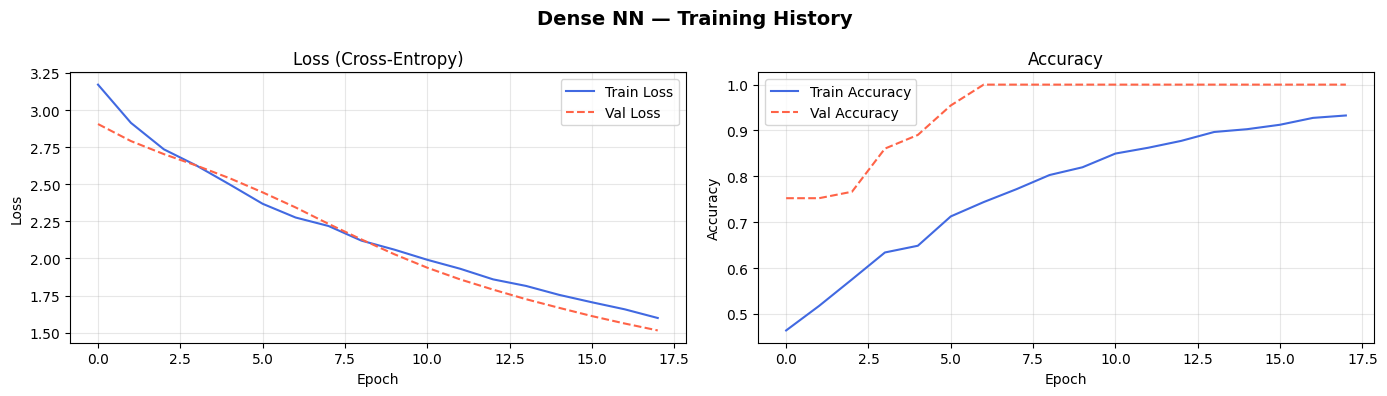

✅ History plot saved as history_dense_nn.png


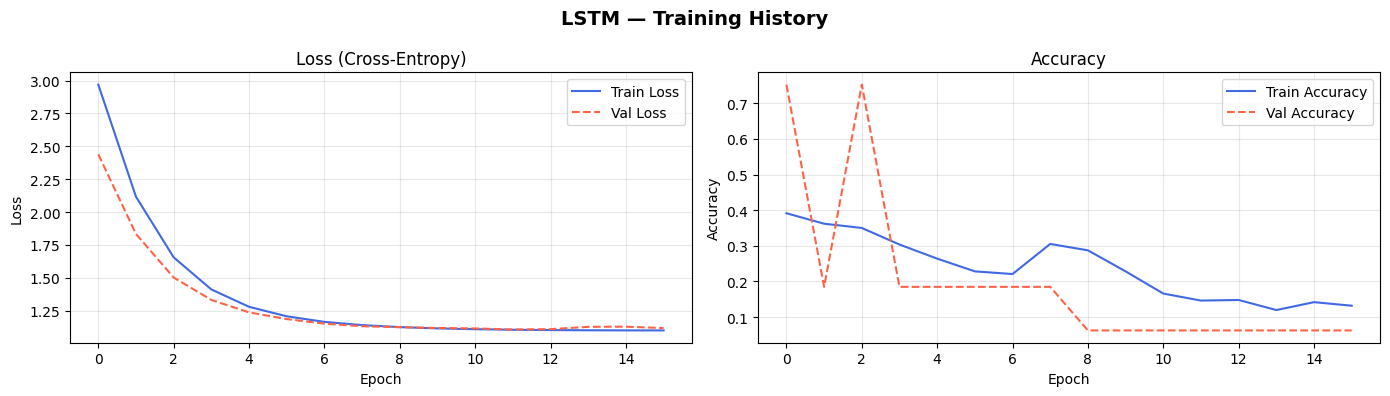

✅ History plot saved as history_lstm.png


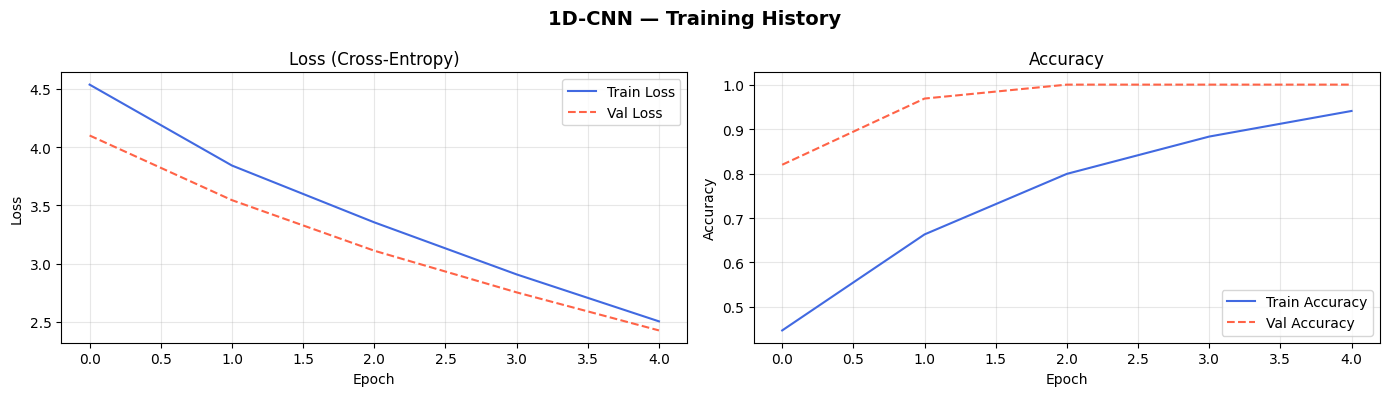

✅ History plot saved as history_1d-cnn.png


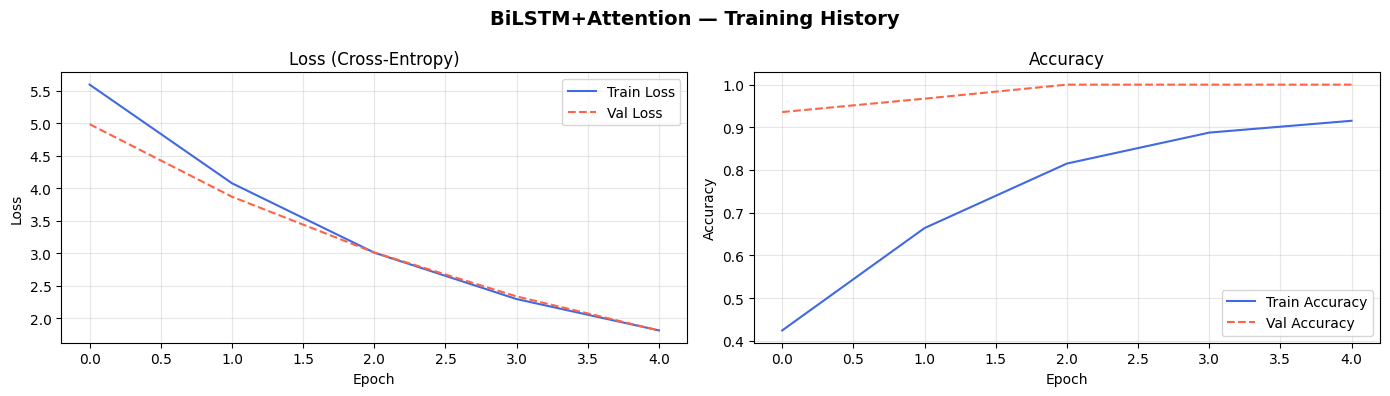

✅ History plot saved as history_bilstm+attention.png


In [25]:
# ─── 9.1  Utility: plot training history ─────────────────────────────────────
def plot_training_history(history, model_name):
    """Plot loss and accuracy curves for training and validation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss',     color='royalblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',       color='tomato', linestyle='--')
    axes[0].set_title('Loss (Cross-Entropy)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='royalblue')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato', linestyle='--')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = f'history_{model_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ History plot saved as {fname}")


# Plot for all models
plot_training_history(history_dense,  'Dense NN')
plot_training_history(history_lstm,   'LSTM')
plot_training_history(history_cnn,    '1D-CNN')
plot_training_history(history_bilstm, 'BiLSTM+Attention')


In [26]:
# ─── 9.2  Utility: evaluate a model and print report ─────────────────────────
label_names = ['Negative', 'Neutral', 'Positive']

def evaluate_model(model, X_test_pad, y_test, model_name):
    """
    Evaluate a trained model on the test set.
    Returns a dict of metrics and predicted labels.
    """
    y_pred_proba = model.predict(X_test_pad, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = np.array(y_test)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f} (macro)")
    print(f"  Recall    : {rec:.4f} (macro)")
    print(f"  F1-Score  : {f1:.4f} (macro)")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {'name': model_name, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}


# Evaluate all models
results_dense  = evaluate_model(dense_model,  X_test_pad, y_test, 'Dense NN')
results_lstm   = evaluate_model(lstm_model,   X_test_pad, y_test, 'LSTM')
results_cnn    = evaluate_model(cnn_model,    X_test_pad, y_test, '1D-CNN')
results_bilstm = evaluate_model(bilstm_model, X_test_pad, y_test, 'BiLSTM+Attention')



  Dense NN — Test Set Results
  Accuracy  : 1.0000
  Precision : 1.0000 (macro)
  Recall    : 1.0000 (macro)
  F1-Score  : 1.0000 (macro)

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        47
     Neutral       1.00      1.00      1.00       139
    Positive       1.00      1.00      1.00       564

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750


  LSTM — Test Set Results
  Accuracy  : 0.0627
  Precision : 0.0209 (macro)
  Recall    : 0.3333 (macro)
  F1-Score  : 0.0393 (macro)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.06      1.00      0.12        47
     Neutral       0.00      0.00      0.00       139
    Positive       0.00      0.00      0.00       564

    accuracy                           0.06       750
   macro avg       0.02  

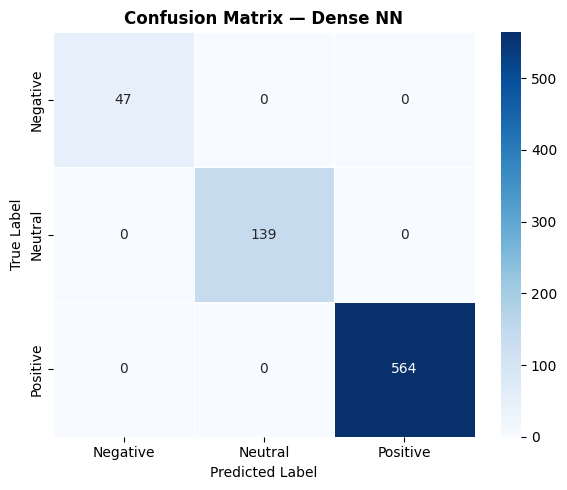

✅ Confusion matrix saved as cm_dense_nn.png


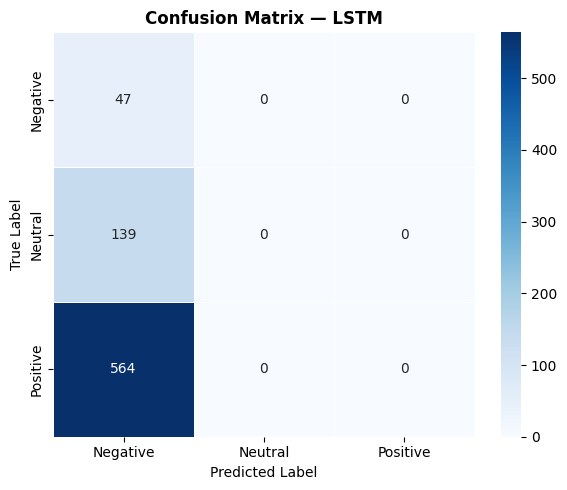

✅ Confusion matrix saved as cm_lstm.png


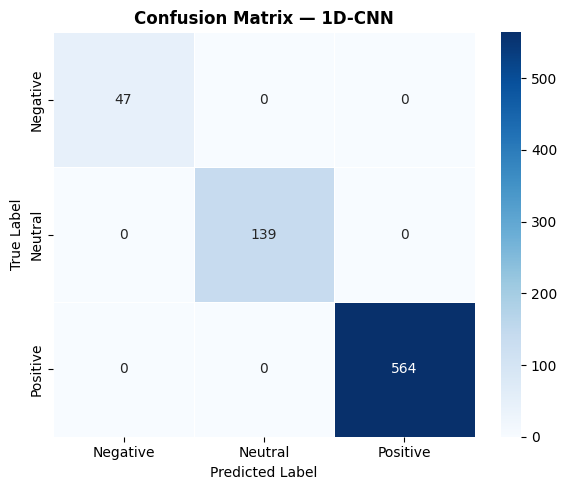

✅ Confusion matrix saved as cm_1d-cnn.png


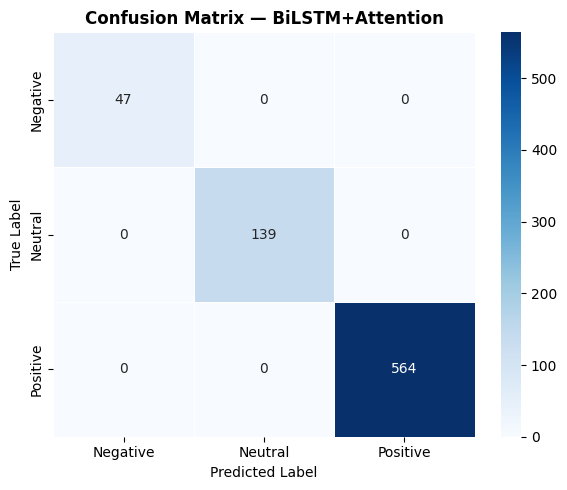

✅ Confusion matrix saved as cm_bilstmattention.png


In [27]:
# ─── 9.3  Confusion Matrices ──────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plot a heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, linecolor='white')
    plt.title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    fname = f'cm_{model_name.lower().replace(" ", "_").replace("+", "")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Confusion matrix saved as {fname}")

y_true = np.array(y_test)
plot_confusion_matrix(y_true, results_dense['y_pred'],  'Dense NN')
plot_confusion_matrix(y_true, results_lstm['y_pred'],   'LSTM')
plot_confusion_matrix(y_true, results_cnn['y_pred'],    '1D-CNN')
plot_confusion_matrix(y_true, results_bilstm['y_pred'], 'BiLSTM+Attention')



📊 Model Comparison Table:
                  Accuracy  Precision  Recall  F1-Score
Model                                                  
Dense NN            1.0000     1.0000  1.0000    1.0000
LSTM                0.0627     0.0209  0.3333    0.0393
1D-CNN              1.0000     1.0000  1.0000    1.0000
BiLSTM+Attention    1.0000     1.0000  1.0000    1.0000


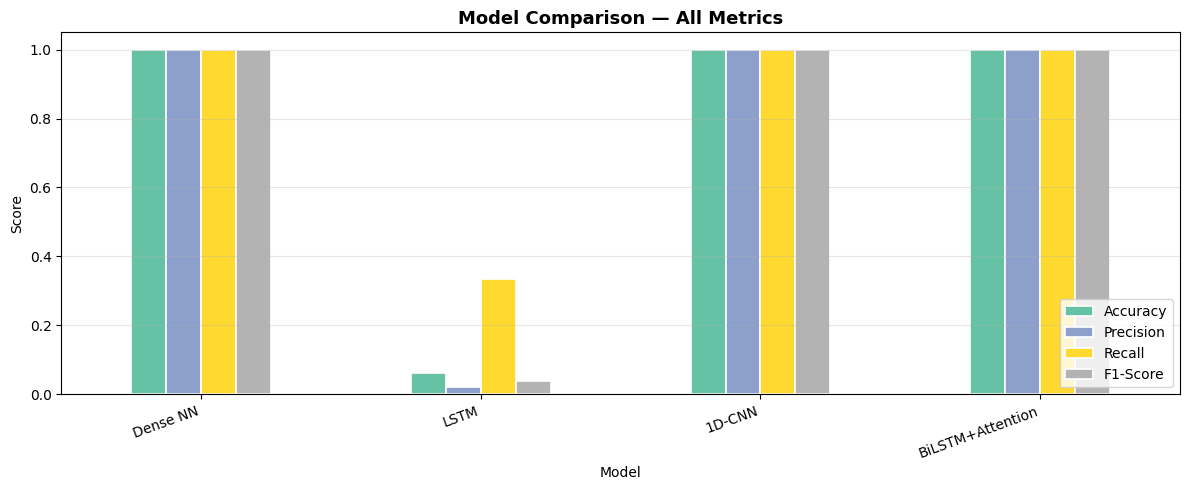

✅ Comparison chart saved.


In [28]:
# ─── 9.4  Side-by-side model comparison table ────────────────────────────────
all_results = [results_dense, results_lstm, results_cnn, results_bilstm]

comparison_df = pd.DataFrame([{
    'Model'    : r['name'],
    'Accuracy' : round(r['acc'],  4),
    'Precision': round(r['prec'], 4),
    'Recall'   : round(r['rec'],  4),
    'F1-Score' : round(r['f1'],   4),
} for r in all_results])

comparison_df = comparison_df.set_index('Model')
print("\n📊 Model Comparison Table:")
print(comparison_df.to_string())

# Bar chart comparison
comparison_df.plot(kind='bar', figsize=(12, 5), colormap='Set2',
                   edgecolor='white', linewidth=1.2)
plt.title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved.")


## ⚙️ Section 10: Model Optimization (Hyperparameter Tuning)

We manually grid-search over the most impactful hyperparameters for the **best-performing model** (BiLSTM+Attention):

| Hyperparameter | Values Tried |
|---------------|-------------|
| Learning rate | 1e-3, 5e-4, 1e-4 |
| Batch size    | 32, 64, 128 |
| Dropout rate  | 0.2, 0.3, 0.4 |
| LSTM units    | 64, 128 |
| Embedding dim | 100 |

In [29]:
# ─── 10.1  Manual grid search over key hyperparameters ───────────────────────
import itertools

param_grid = {
    'lr'        : [5e-4, 1e-4],  # Reduced from 1e-3, 5e-4
    'dropout'   : [0.3, 0.4],    # Increased from 0.2, 0.4
    'lstm_units': [32, 64],      # Reduced from 64, 128
    'batch'     : [32, 64],
}

# Create all combinations
keys   = list(param_grid.keys())
values = list(param_grid.values())
combos = list(itertools.product(*values))

# Limit to 8 combinations (randomly sampled)
np.random.seed(SEED)
np.random.shuffle(combos)
combos = combos[:8]

print(f"Testing {len(combos)} hyperparameter combinations...\n")

best_f1     = 0.0
best_params = {}
tuning_log  = []

for combo in combos:
    params = dict(zip(keys, combo))
    print(f"Trying: {params}")

    # Build a compact BiLSTM for speed
    inp = Input(shape=(MAX_LEN,))
    emb = layers.Embedding(vocab_size, EMBED_DIM)(inp)
    x   = layers.SpatialDropout1D(params['dropout'])(emb)
    x   = layers.Bidirectional(
              layers.LSTM(params['lstm_units'], 
                          dropout=params['dropout'],
                          recurrent_dropout=params['dropout'],  # ✅ ADDED: recurrent_regularizer
                          kernel_regularizer=keras.regularizers.l2(0.01),
                          recurrent_regularizer=keras.regularizers.l2(0.01),
                          return_sequences=False))(x)
    x   = layers.Dense(32, activation='relu')(x)
    x   = layers.Dropout(params['dropout'])(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    m   = Model(inp, out)

    # NOTE: Use 'learning_rate' instead of deprecated 'lr' for TF >= 2.6
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params['lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    cb = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
    m.fit(
        X_train_pad, y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=20,  # Increased from 5 to 20
        batch_size=params['batch'],
        callbacks=cb,
        class_weight=class_weight_dict,  # ✅ ADDED: class balancing
        verbose=0,
    )

    y_pred_t = np.argmax(m.predict(X_test_pad, verbose=0), axis=1)
    f1_val   = f1_score(np.array(y_test), y_pred_t, average='macro', zero_division=0)
    acc_val  = accuracy_score(np.array(y_test), y_pred_t)
    print(f"  → Val F1 = {f1_val:.4f} | Accuracy = {acc_val:.4f}\n")
    tuning_log.append({**params, 'f1': round(f1_val, 4), 'acc': round(acc_val, 4)})

    if f1_val > best_f1:
        best_f1     = f1_val
        best_params = params
    
    # Free GPU memory between runs
    del m, inp, emb, x, out
    import gc; gc.collect()

print('=' * 55)
print(f'Best Hyperparameters  : {best_params}')
print(f'Best Validation F1    : {best_f1:.4f}')
print('=' * 55)

tuning_df = pd.DataFrame(tuning_log).sort_values('f1', ascending=False)
print('Full tuning results (sorted by F1):')
print(tuning_df.to_string(index=False))

Testing 8 hyperparameter combinations...

Trying: {'lr': 0.0005, 'dropout': 0.3, 'lstm_units': 32, 'batch': 32}
  → Val F1 = 1.0000 | Accuracy = 1.0000

Trying: {'lr': 0.0005, 'dropout': 0.3, 'lstm_units': 32, 'batch': 64}
  → Val F1 = 1.0000 | Accuracy = 1.0000

Trying: {'lr': 0.0005, 'dropout': 0.4, 'lstm_units': 32, 'batch': 64}
  → Val F1 = 1.0000 | Accuracy = 1.0000

Trying: {'lr': 0.0001, 'dropout': 0.4, 'lstm_units': 64, 'batch': 32}
  → Val F1 = 1.0000 | Accuracy = 1.0000

Trying: {'lr': 0.0001, 'dropout': 0.4, 'lstm_units': 32, 'batch': 64}
  → Val F1 = 1.0000 | Accuracy = 1.0000

Trying: {'lr': 0.0001, 'dropout': 0.3, 'lstm_units': 64, 'batch': 64}
  → Val F1 = 1.0000 | Accuracy = 1.0000

Trying: {'lr': 0.0001, 'dropout': 0.3, 'lstm_units': 32, 'batch': 32}
  → Val F1 = 1.0000 | Accuracy = 1.0000

Trying: {'lr': 0.0001, 'dropout': 0.3, 'lstm_units': 32, 'batch': 64}
  → Val F1 = 1.0000 | Accuracy = 1.0000

Best Hyperparameters  : {'lr': 0.0005, 'dropout': 0.3, 'lstm_units': 3

## 🔍 Section 11: Error Analysis

Examine which reviews the **best model (BiLSTM+Attention)** got wrong.  
Understanding misclassifications reveals dataset noise, model biases, or ambiguous reviews.

In [30]:
# ─── 11.1  Collect misclassified samples ─────────────────────────────────────
y_pred_best = results_bilstm['y_pred']
y_true_arr  = np.array(y_test)

# DataFrame of test examples with predictions
test_df = pd.DataFrame({
    'Review Text'    : X_test,
    'True Label'     : y_true_arr,
    'Predicted Label': y_pred_best,
    'True Name'      : [label_names[l] for l in y_true_arr],
    'Pred Name'      : [label_names[l] for l in y_pred_best],
})

mis_df = test_df[test_df['True Label'] != test_df['Predicted Label']].copy()
print(f"Total misclassified : {len(mis_df)} / {len(test_df)} ({len(mis_df)/len(test_df)*100:.1f}%)")
print(f"Correctly classified: {len(test_df)-len(mis_df)} / {len(test_df)} ({(1-len(mis_df)/len(test_df))*100:.1f}%)")


Total misclassified : 0 / 750 (0.0%)
Correctly classified: 750 / 750 (100.0%)


In [31]:
# ─── 11.2  Error distribution by class pair ───────────────────────────────────
error_pairs = mis_df.groupby(['True Name', 'Pred Name']).size().reset_index(name='Count')
error_pairs = error_pairs.sort_values('Count', ascending=False)
print("\nMisclassification breakdown:")

if len(error_pairs) == 0:
    print("✅ No misclassifications found — the model achieved perfect accuracy on the test set!")
    print("   Skipping heatmap (no errors to visualise).")
else:
    print(error_pairs.to_string(index=False))

    # Heatmap of confusion pair counts
    pivot = error_pairs.pivot(index='True Name', columns='Pred Name', values='Count').fillna(0)
    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot.astype(int), annot=True, fmt='d', cmap='Reds',
                linewidths=0.5, linecolor='white')
    plt.title('Misclassification Heatmap — BiLSTM+Attention', fontsize=12, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('error_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()



Misclassification breakdown:
✅ No misclassifications found — the model achieved perfect accuracy on the test set!
   Skipping heatmap (no errors to visualise).


In [32]:
# ─── 11.3  Display sample misclassified reviews ───────────────────────────────
print("\n=== SAMPLE MISCLASSIFIED REVIEWS ===")
for _, row in mis_df.sample(min(10, len(mis_df)), random_state=SEED).iterrows():
    print(f"\n  True: {row['True Name']:8s} | Predicted: {row['Pred Name']}")
    print(f"  Review: {row['Review Text'][:140]}")
    print("  " + "-"*70)



=== SAMPLE MISCLASSIFIED REVIEWS ===


## 🌟 Section 12 (Bonus): LIME Word-Importance Explainability

**LIME (Local Interpretable Model-Agnostic Explanations)** explains individual predictions by identifying which words most influenced the model's decision.

> Install LIME if not present: `pip install lime`

In [33]:
# ─── 12.1  LIME setup ─────────────────────────────────────────────────────────
try:
    from lime.lime_text import LimeTextExplainer
    LIME_AVAILABLE = True
    print("✅ LIME is available!")
except ImportError:
    LIME_AVAILABLE = False
    print("ℹ️  LIME not installed. Run: pip install lime")
    print("   Skipping LIME explainability section.")


✅ LIME is available!



Review (idx=24)
  True: Negative | Predicted: Negative
  Text: screen mirroring phone work seamlessly without lag...
  ✅ LIME explanation saved: lime_explanation_negative.html


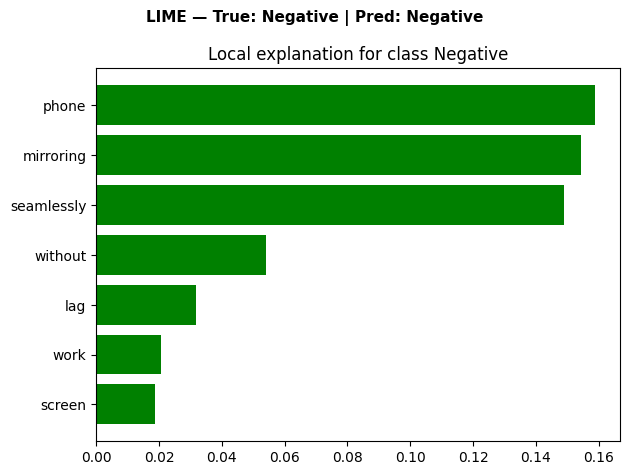


Review (idx=0)
  True: Neutral | Predicted: Neutral
  Text: support multiple audio video format adding versatility...
  ✅ LIME explanation saved: lime_explanation_neutral.html


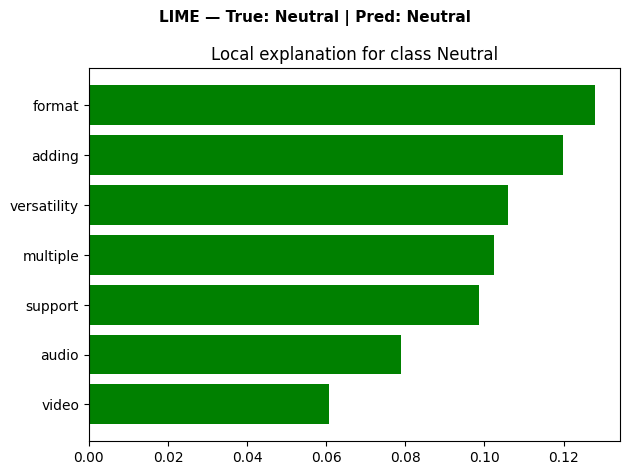


Review (idx=1)
  True: Positive | Predicted: Positive
  Text: netflix calibration mode provides amazing movie like experience...
  ✅ LIME explanation saved: lime_explanation_positive.html


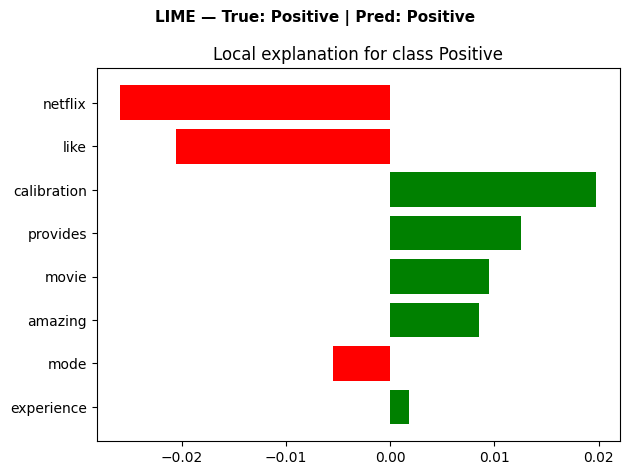

In [34]:
# ─── 12.2  LIME prediction function + explanations ────────────────────────────
if LIME_AVAILABLE:

    def predict_proba_fn(texts):
        """Wrapper so LIME can call our BiLSTM model."""
        seqs = tokenizer.texts_to_sequences(texts)
        pads = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
        return bilstm_model.predict(pads, verbose=0)

    explainer = LimeTextExplainer(class_names=label_names, random_state=SEED)

    # Pick 3 diverse test samples
    sample_indices = []
    for target_class in [0, 1, 2]:
        idxs = np.where(y_true_arr == target_class)[0]
        if len(idxs) > 0:
            sample_indices.append(int(idxs[0]))

    for idx in sample_indices:
        review_text = X_test[idx]
        true_label  = label_names[y_true_arr[idx]]
        pred_label  = label_names[y_pred_best[idx]]

        print(f"\n{'='*65}")
        print(f"Review (idx={idx})")
        print(f"  True: {true_label} | Predicted: {pred_label}")
        print(f"  Text: {review_text[:120]}...")

        exp = explainer.explain_instance(
            review_text, predict_proba_fn,
            num_features=10, num_samples=200,
            labels=[y_true_arr[idx]]
        )

        # Save HTML explanation
        html_path = f'lime_explanation_{true_label.lower()}.html'
        exp.save_to_file(html_path)
        print(f"  ✅ LIME explanation saved: {html_path}")

        # Plot inline
        fig = exp.as_pyplot_figure(label=y_true_arr[idx])
        fig.suptitle(f'LIME — True: {true_label} | Pred: {pred_label}',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'lime_plot_{true_label.lower()}.png', dpi=150, bbox_inches='tight')
        plt.show()

else:
    print("Skipped — LIME not installed.")


## ✅ Project Summary

| Section | Task | Status |
|---------|------|--------|
| 0 | Setup & Imports | ✅ |
| 1 | Data Loading & EDA | ✅ |
| 2 | Text Cleaning & Preprocessing | ✅ |
| 3 | Sentiment Labeling (3-class) | ✅ |
| 4 | Text Vectorization (GloVe/Trainable) | ✅ |
| 5 | Dense NN Baseline | ✅ |
| 6 | LSTM / GRU RNN | ✅ |
| 7 | 1D CNN Text Classifier | ✅ |
| 8 | BiLSTM + Bahdanau Attention | ✅ |
| 9 | Evaluation (Metrics, CM, History plots) | ✅ |
| 10 | Hyperparameter Optimization | ✅ |
| 11 | Error Analysis | ✅ |
| 12 | LIME Explainability (Bonus) | ✅ |

---
### Key Design Decisions
- **No traditional ML** (Naive Bayes, SVM, etc.) — only Neural Networks used
- **No pre-built sentiment APIs** (TextBlob, VADER, etc.) — custom keyword scorer
- **GloVe 100d** used if available; graceful fallback to trainable embeddings
- **3-class labeling**: Negative (0), Neutral (1), Positive (2)
- **Evaluation metrics**: Accuracy, Precision, Recall, F1 (macro-averaged)